In [1]:
# HR Workforce & Attrition Analytics

##1. Data Loading & Understanding

In [2]:
import pandas as pd
df = pd.read_csv('HR_Analytics.csv')
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [4]:
df.shape

(1480, 38)

In [5]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   str    
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   str    
 3   Attrition                 1480 non-null   str    
 4   BusinessTravel            1480 non-null   str    
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   str    
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   str    
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   str    
 14  HourlyRate         

In [7]:
df.isnull().sum()

EmpID                        0
Age                          0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
SalarySlab                   0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
StandardHours                0
StockOptionLevel             0
TotalWorkingYears            0
Training

In [8]:
df.duplicated().sum()

np.int64(7)

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,...,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1423.000000
mean,36.917568,801.384459,9.220270,2.910811,1.0,1031.860811,2.724324,65.845270,2.729730,2.064865,...,2.708784,80.0,0.791892,11.281757,2.797973,2.760811,7.009459,4.228378,2.182432,4.118060
std,9.128559,403.126988,8.131201,1.023796,0.0,605.955046,1.092579,20.328266,0.713007,1.105574,...,1.081995,0.0,0.850527,7.770870,1.288791,0.707024,6.117945,3.616020,3.219357,3.555484
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,493.750000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,800.000000,7.000000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1568.250000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
df.select_dtypes(include="object").nunique()

C:\Users\asus\AppData\Local\Temp\ipykernel_27636\251659734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique()


EmpID             1470
AgeGroup             5
Attrition            2
BusinessTravel       4
Department           3
EducationField       6
Gender               2
JobRole              9
MaritalStatus        3
SalarySlab           4
Over18               1
OverTime             2
dtype: int64

In [13]:
df["Attrition"].value_counts()

Attrition
No     1242
Yes     238
Name: count, dtype: int64

In [14]:
df["Department"].value_counts()

Department
Research & Development    967
Sales                     450
Human Resources            63
Name: count, dtype: int64

In [15]:
df["JobRole"].value_counts()

JobRole
Sales Executive              329
Research Scientist           293
Laboratory Technician        261
Manufacturing Director       147
Healthcare Representative    132
Manager                      102
Sales Representative          84
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [16]:
df["OverTime"].value_counts()

OverTime
No     1062
Yes     418
Name: count, dtype: int64

In [17]:
df['EmpID'].duplicated().sum()

np.int64(10)

In [18]:
df[df['EmpID'].duplicated(keep=False)].sort_values('EmpID')

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
327,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
1335,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
952,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
457,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
161,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,0.0
162,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,5.0


In [19]:
df.duplicated().sum()

np.int64(7)

In [20]:
df[df.duplicated(keep=False)].sort_values("EmpID")

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
327,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
328,RM1461,29,26-35,No,Travel_Rarely,468,Research & Development,28,4,Medical,...,2,80,0,5,3,1,5,4,0,4.0
1335,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
1336,RM1462,50,46-55,Yes,Travel_Rarely,410,Sales,28,3,Marketing,...,2,80,1,20,3,3,3,2,2,0.0
952,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
954,RM1463,39,36-45,No,Travel_Rarely,722,Sales,24,1,Marketing,...,1,80,1,21,2,2,20,9,9,6.0
457,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
458,RM1464,31,26-35,No,Non-Travel,325,Research & Development,5,3,Medical,...,2,80,0,10,2,3,9,4,1,7.0
210,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0
211,RM1468,27,26-35,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,...,2,80,1,6,0,3,6,2,0,3.0


In [21]:
duplicate_ids = df[df["EmpID"].duplicated(keep=False)]

duplicate_ids[
    ~duplicate_ids.duplicated(keep=False)
].sort_values("EmpID")

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
161,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,0.0
162,RM1465,26,26-35,No,Travel_Rarely,1167,Sales,5,3,Other,...,4,80,0,5,2,3,4,2,0,5.0
802,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,80,1,17,3,3,5,2,0,3.0
803,RM1466,36,36-45,No,Travel_Frequently,884,Research & Development,23,2,Medical,...,3,80,1,17,3,3,5,2,0,2.0
953,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,1,80,1,9,5,3,7,7,1,7.0
955,RM1467,39,36-45,No,Travel_Rarely,613,Research & Development,6,1,Medical,...,1,80,1,9,5,3,7,7,1,1.0


In [24]:
clean_df = df.copy()

In [25]:
clean_df = clean_df.drop_duplicates()

In [26]:
clean_df.shape

(1473, 38)

In [27]:
conflicting_ids = ['RM1465','RM1466','RM1467']
clean_df.loc[
    clean_df['EmpID'].isin(conflicting_ids),"YearsWithCurrManager"] = pd.NA

In [28]:
clean_df[clean_df["EmpID"].isin(conflicting_ids)][
    ["EmpID", "YearsAtCompany", "YearsWithCurrManager"]
]

,EmpID,YearsAtCompany,YearsWithCurrManager
161,RM1465,4,NaN
162,RM1465,4,NaN
802,RM1466,5,NaN
803,RM1466,5,NaN
953,RM1467,7,NaN
955,RM1467,7,NaN


In [29]:
clean_df = clean_df.drop_duplicates()

In [30]:
clean_df.shape


(1470, 38)

In [31]:
clean_df['EmpID'].duplicated().sum()

np.int64(0)

In [32]:
clean_df.duplicated().sum()

np.int64(0)

In [33]:
clean_df = clean_df.drop(
    columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])

In [34]:
clean_df.shape

(1470, 34)

In [35]:
clean_df.isnull().sum().sort_values(ascending=False)

YearsWithCurrManager        60
EmpID                        0
Age                          0
AgeGroup                     0
BusinessTravel               0
Attrition                    0
Department                   0
DistanceFromHome             0
Education                    0
DailyRate                    0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
EducationField               0
MaritalStatus                0
MonthlyIncome                0
MonthlyRate                  0
SalarySlab                   0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
NumCompaniesWorked           0
RelationshipSatisfaction     0
StockOptionLevel             0
TrainingTimesLastYear        0
TotalWorkingYears            0
WorkLifeBalance              0
YearsAtCompany               0
YearsInC

In [36]:
clean_df['YearsWithCurrManager'].isnull().sum()

np.int64(60)

In [37]:
clean_df.to_csv('HR_Analytics_Cleaned.csv',index=False)

In [38]:
clean_df.columns = clean_df.columns.str.replace(
    r'(?<!^)(?=[A-Z])', '_', regex=True
).str.lower()

In [39]:
clean_df.columns

Index(['emp_i_d', 'age', 'age_group', 'attrition', 'business_travel',
       'daily_rate', 'department', 'distance_from_home', 'education',
       'education_field', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'salary_slab', 'monthly_rate',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='str')

In [40]:
clean_df.to_csv("HR_Analytics_Cleaned.csv", index=False)

In [41]:
total_employees = clean_df['emp_id'].nunique()
average_age = clean_df['age'].mean()
average_income = clean_df['monthly_income'].mean()
average_years_at_company = clean_df['years_at_company'].mean()

print("Total Employees: ",total_employees)
print("Average Age: ",round(average_age,2))
print("Average Monthly Income: ",round(average_incomee,2))
print("Average Years at Company: ",round(average_years,2))

KeyError: 'emp_id'

In [43]:
clean_df = clean_df.rename(columns={"emp_i_d": "emp_id"})

In [44]:
clean_df.columns

Index(['emp_id', 'age', 'age_group', 'attrition', 'business_travel',
       'daily_rate', 'department', 'distance_from_home', 'education',
       'education_field', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'salary_slab', 'monthly_rate',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='str')

In [45]:
total_employees = clean_df["emp_id"].nunique()
average_age = clean_df["age"].mean()
average_income = clean_df["monthly_income"].mean()
average_years_at_company = clean_df["years_at_company"].mean()

print("Total Employees:", total_employees)
print("Average Age:", round(average_age, 2))
print("Average Monthly Income:", round(average_income, 2))
print("Average Years at Company:", round(average_years_at_company, 2))

Total Employees: 1470
Average Age: 36.92
Average Monthly Income: 6502.93
Average Years at Company: 7.01


In [46]:
department_counts = clean_df['department'].value_counts()
print(department_counts)

department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


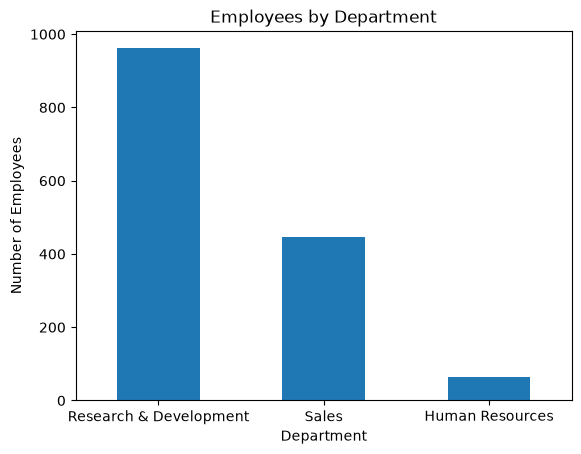

In [47]:
import matplotlib.pyplot as plt

department_counts.plot(kind="bar")

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

In [48]:
gender_counts = clean_df['gender'].value_counts()
print(gender_counts)

gender
Male      882
Female    588
Name: count, dtype: int64


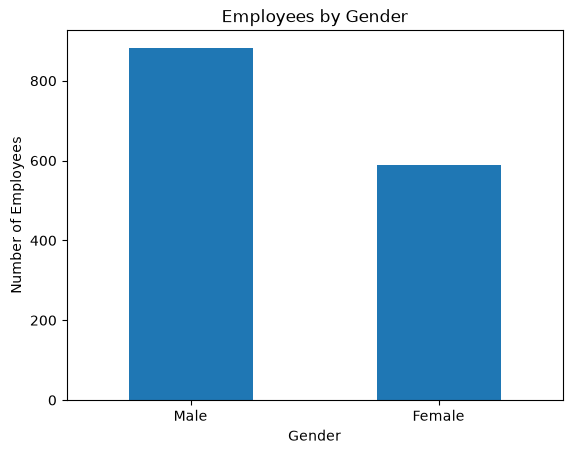

In [52]:
gender_counts.plot(kind="bar")

plt.title("Employees by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

In [55]:
age_group_counts = clean_df["age_group"].value_counts().sort_index()

print(age_group_counts)

age_group
18-25    123
26-35    606
36-45    468
46-55    226
55+       47
Name: count, dtype: int64


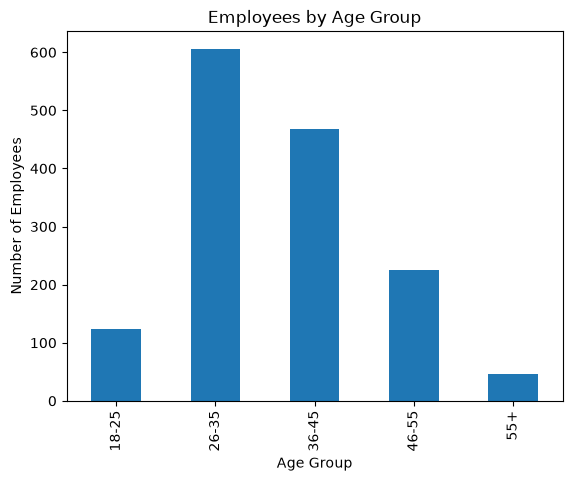

In [57]:
job_role_counts = clean_df['job_role'].value_counts()
print(job_role_counts)

job_role
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


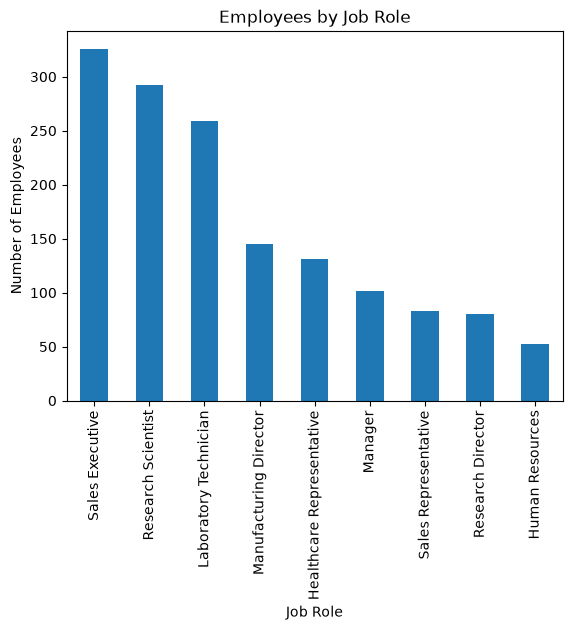

In [58]:
job_role_counts.plot(kind='bar')

plt.title('Employees by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.show()

In [59]:
## Attrition EDA

In [60]:
attrition_counts = clean_df['attrition'].value_counts()
print(attrition_counts)

attrition
No     1233
Yes     237
Name: count, dtype: int64


In [61]:
attrition_rate = (
    clean_df['attrition'].value_counts(normalize=True) * 100)
print(attrition_rate)

attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [62]:
department_attrition = clean_df.groupby("department")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

In [63]:
print(department_attrition)

department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: attrition, dtype: float64


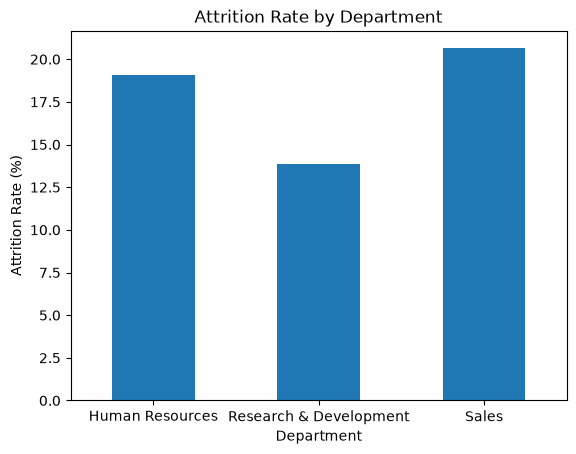

In [65]:
department_attrition.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [66]:
job_role_attrition = clean_df.groupby('job_role')['attrition'].apply(
    lambda x: (x=='Yes').mean() *100
)

In [67]:
print(job_role_attrition)

job_role
Healthcare Representative     6.870229
Human Resources              23.076923
Laboratory Technician        23.938224
Manager                       4.901961
Manufacturing Director        6.896552
Research Director             2.500000
Research Scientist           16.095890
Sales Executive              17.484663
Sales Representative         39.759036
Name: attrition, dtype: float64


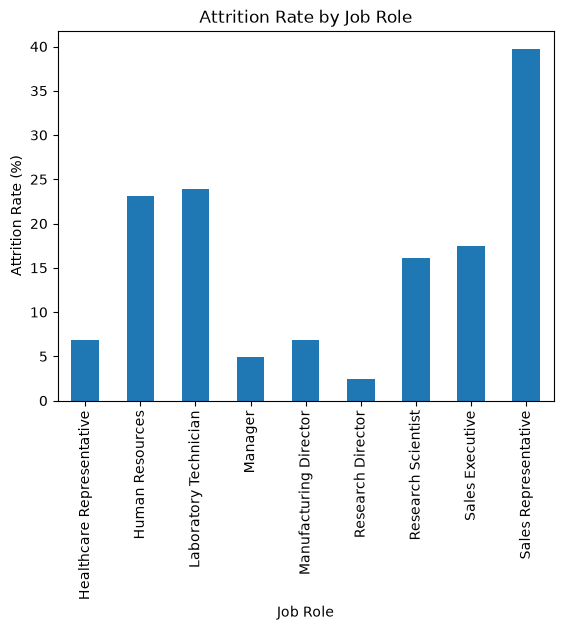

In [69]:
job_role_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [70]:
gender_attrition = clean_df.groupby('gender')['attrition'].apply(
    lambda x: (x=='Yes').mean() * 100
)

print(gender_attrition)

gender
Female    14.795918
Male      17.006803
Name: attrition, dtype: float64


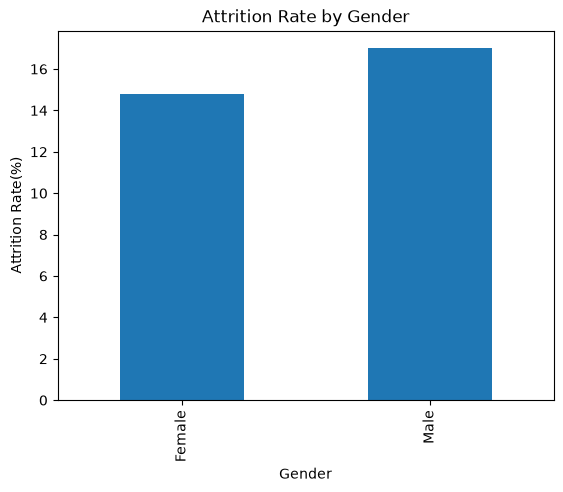

In [72]:
gender_attrition.plot(kind='bar')

plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate(%)')
plt.show()

In [73]:
age_group_attrition = clean_df.groupby("age_group")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(age_group_attrition)

age_group
18-25    35.772358
26-35    19.141914
36-45     9.188034
46-55    11.504425
55+      17.021277
Name: attrition, dtype: float64


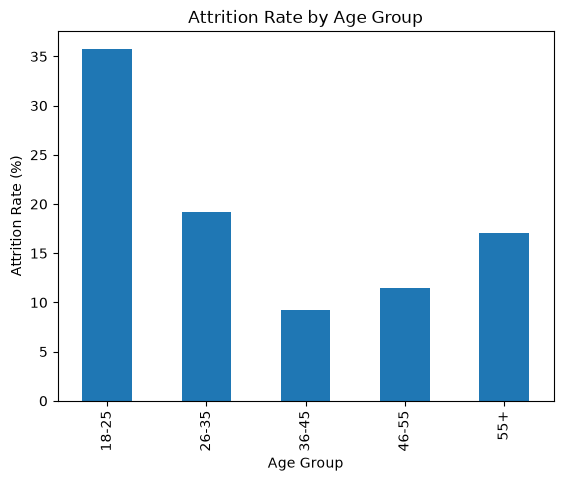

In [74]:
age_group_attrition.plot(kind="bar")

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [76]:
overtime_attrition = clean_df.groupby("over_time")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(overtime_attrition)

over_time
No     10.436433
Yes    30.528846
Name: attrition, dtype: float64


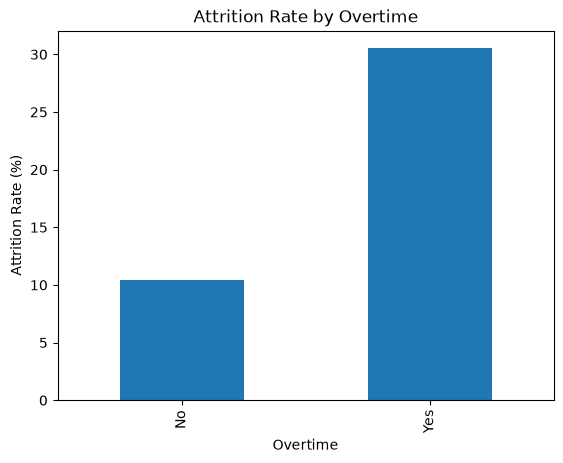

In [77]:
overtime_attrition.plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [78]:
satisfaction_attrition = clean_df.groupby("job_satisfaction")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(satisfaction_attrition)

job_satisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: attrition, dtype: float64


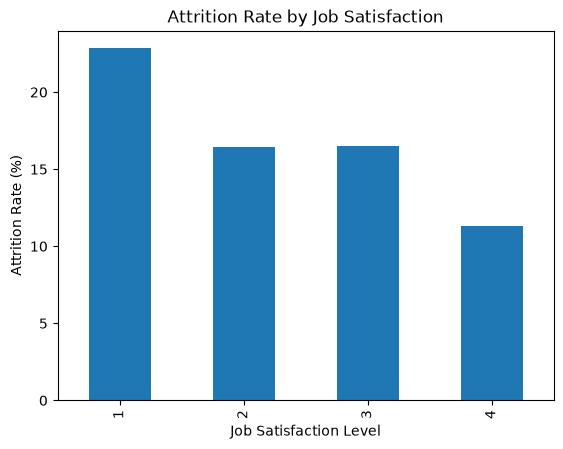

In [79]:
satisfaction_attrition.plot(kind="bar")

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [80]:
worklife_attrition = clean_df.groupby("work_life_balance")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(worklife_attrition)

work_life_balance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: attrition, dtype: float64


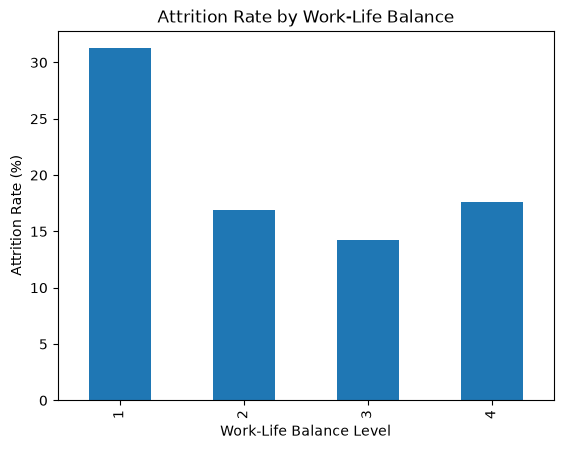

In [81]:
worklife_attrition.plot(kind="bar")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Level")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [82]:
salary_attrition = clean_df.groupby("salary_slab")["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(salary_attrition)

salary_slab
10k-15k    13.513514
15k+        3.759398
5k-10k     11.136364
Upto 5k    21.762350
Name: attrition, dtype: float64


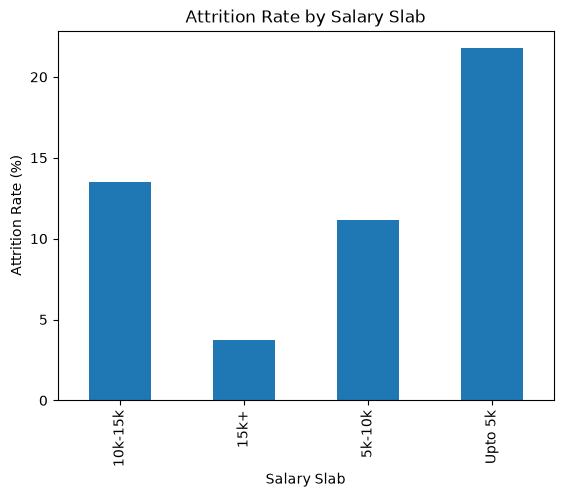

In [83]:
salary_attrition.plot(kind="bar")

plt.title("Attrition Rate by Salary Slab")
plt.xlabel("Salary Slab")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [90]:
clean_df['tenure_group'] = pd.cut(
    clean_df['years_at_company'],
    bins=[-1,2,5,10,15,float('inf')],
    labels=['0-2','3-5','6-10','11-15','16+']
)

In [86]:
clean_df.columns


Index(['emp_id', 'age', 'age_group', 'attrition', 'business_travel',
       'daily_rate', 'department', 'distance_from_home', 'education',
       'education_field', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'salary_slab', 'monthly_rate',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='str')

In [91]:
clean_df["tenure_group"].value_counts().sort_index()

tenure_group
0-2      342
3-5      434
6-10     448
11-15    108
16+      138
Name: count, dtype: int64

In [92]:
tenure_attrition = clean_df.groupby("tenure_group", observed=True)["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(tenure_attrition)

tenure_group
0-2      29.824561
3-5      13.824885
6-10     12.276786
11-15     6.481481
16+       9.420290
Name: attrition, dtype: float64


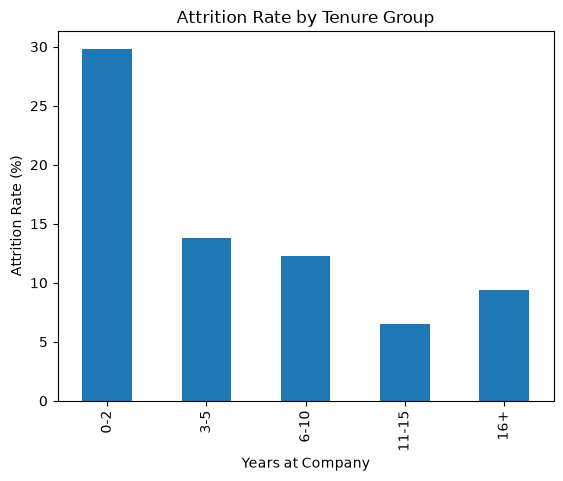

In [93]:
tenure_attrition.plot(kind="bar")

plt.title("Attrition Rate by Tenure Group")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [94]:
clean_df["distance_group"] = pd.cut(
    clean_df["distance_from_home"],
    bins=[0, 5, 10, 20, float("inf")],
    labels=["0-5", "6-10", "11-20", "21+"]
)

In [95]:
distance_attrition = clean_df.groupby(
    "distance_group", observed=True
)["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(distance_attrition)

distance_group
0-5      13.765823
6-10     14.467005
11-20    20.000000
21+      22.058824
Name: attrition, dtype: float64


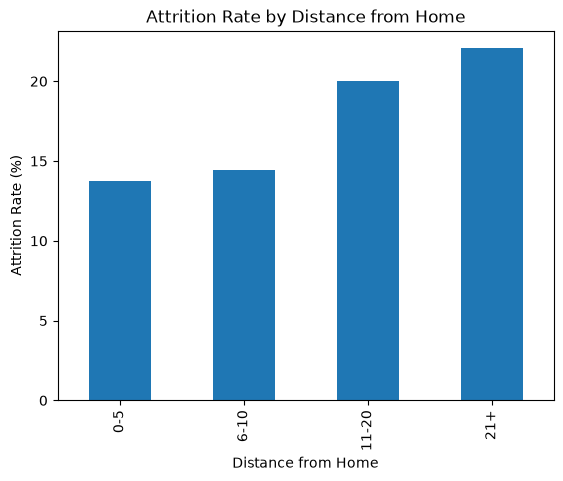

In [96]:
distance_attrition.plot(kind="bar")

plt.title("Attrition Rate by Distance from Home")
plt.xlabel("Distance from Home")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [97]:
clean_df["promotion_group"] = pd.cut(
    clean_df["years_since_last_promotion"],
    bins=[-1, 2, 5, 10, float("inf")],
    labels=["0-2", "3-5", "6-10", "11+"]
)

In [98]:
promotion_attrition = clean_df.groupby(
    "promotion_group", observed=True
)["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(promotion_attrition)

promotion_group
0-2     16.955333
3-5     10.126582
6-10    18.120805
11+     12.121212
Name: attrition, dtype: float64


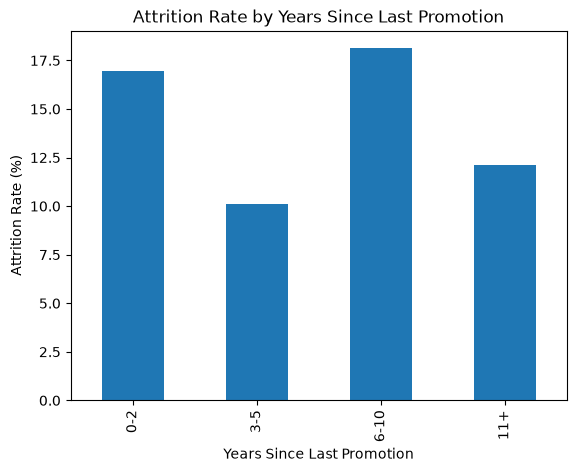

In [99]:
promotion_attrition.plot(kind="bar")

plt.title("Attrition Rate by Years Since Last Promotion")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [100]:
environment_attrition = clean_df.groupby(
    "environment_satisfaction"
)["attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

print(environment_attrition)

environment_satisfaction
1    25.352113
2    14.982578
3    13.686534
4    13.452915
Name: attrition, dtype: float64


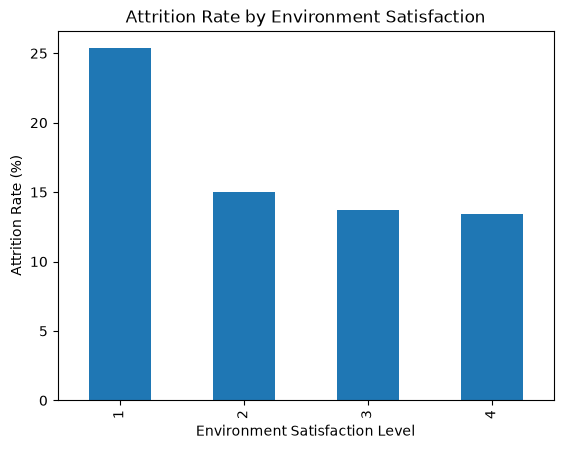

In [101]:
environment_attrition.plot(kind="bar")

plt.title("Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [103]:
clean_df.isnull().sum()

emp_id                         0
age                            0
age_group                      0
attrition                      0
business_travel                0
daily_rate                     0
department                     0
distance_from_home             0
education                      0
education_field                0
environment_satisfaction       0
gender                         0
hourly_rate                    0
job_involvement                0
job_level                      0
job_role                       0
job_satisfaction               0
marital_status                 0
monthly_income                 0
salary_slab                    0
monthly_rate                   0
num_companies_worked           0
over_time                      0
percent_salary_hike            0
performance_rating             0
relationship_satisfaction      0
stock_option_level             0
total_working_years            0
training_times_last_year       0
work_life_balance              0
years_at_c

In [104]:
clean_df.to_csv("HR_Analytics_Final.csv", index=False)

In [105]:
clean_df.shape

(1470, 37)

In [106]:
import os

os.path.exists("HR_Analytics_Final.csv")

True

In [107]:
import pandas as pd
from sqlalchemy import create_engine

In [110]:
from sqlalchemy import create_engine

username = "postgres"
password = "Nischay_123"
host = "localhost"
port = "5432"
database = "hr_analytics"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

with engine.connect() as connection:
    print("PostgreSQL connection successful!")

PostgreSQL connection successful!


In [111]:
table_name = "hr_employee_data"

clean_df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print("HR data successfully loaded into PostgreSQL!")

HR data successfully loaded into PostgreSQL!
